In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read in the images

In [2]:
print("\n\n\n***\n*** Read in the data\n***\n")
print("> loading with ImageFolder (== image_dataset_from_directory)")

image_size = 180
batch_size = 99

# Preprocess (augment) the image data
def make_transforms():
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),  # == image_size=(180, 180) in the dataset
        transforms.ToTensor(),                        # HWC -> CHW and scales by 1/255 (Rescaling)
        transforms.RandomHorizontalFlip(p=0.5),      # layers.RandomFlip("horizontal")
        transforms.RandomRotation(36),              # layers.RandomRotation(0.1): ±0.1*2*pi rad = ±36 deg
    ])

# ImageFolder: each subfolder of "PetImages" is a class, sorted alphabetically (Cat=0, Dog=1)
dataset = datasets.ImageFolder("PetImages", transform=make_transforms())

train_ds, val_ds = random_split(
    dataset,
    [int(0.75 * len(dataset)), len(dataset) - int(0.75 * len(dataset))],
    generator=torch.Generator().manual_seed(123),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)




***
*** Read in the data
***

> loading with ImageFolder (== image_dataset_from_directory)


# Plot some images

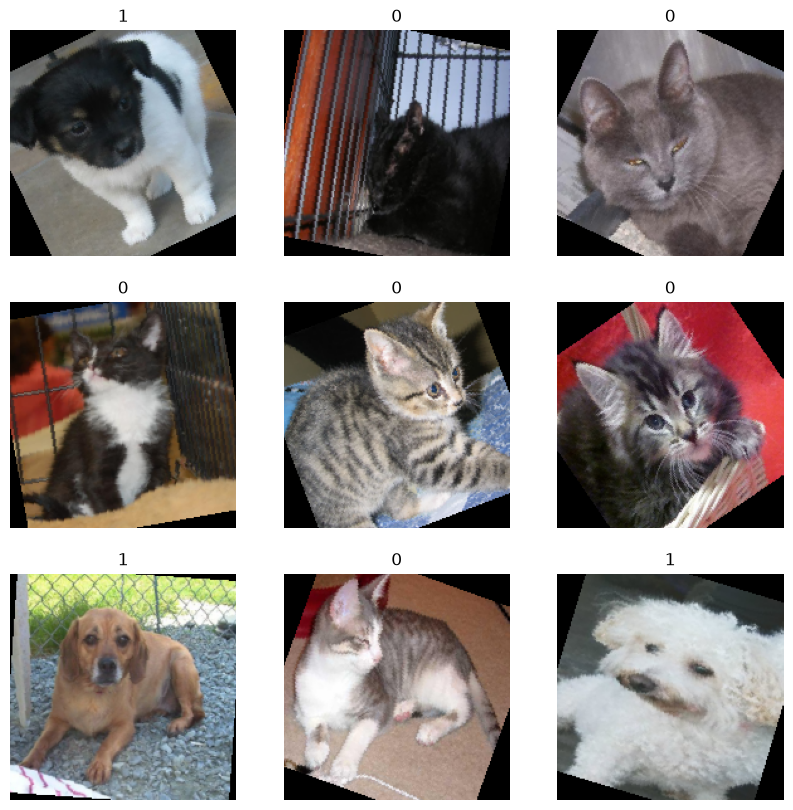

In [3]:
plt.figure(figsize=(10, 10))
images, labels = next(iter(train_loader))   # first batch: (99, 3, 180, 180), (99,)
for i in range(9):                          # plot 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].permute(1, 2, 0)) # CHW -> HWC for matplotlib
    plt.title(int(labels[i]))
    plt.axis("off")
plt.savefig("example_image.png")
plt.show()

# Build the model

In [4]:
class CatDogNet(nn.Module):

    def __init__(self, image_size=180):
        super().__init__()
        # Keras's Conv2D defaults to padding='valid', so no padding here either
        self.features = nn.Sequential(
            # First Convolutional Block
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            # Second Convolutional Block
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            # Third Convolutional Block
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
        )
        # Figure out the size of the flattened vector (Keras does this automatically)
        with torch.no_grad():
            flat_dim = self.features(torch.zeros(1, 3, image_size, image_size)).flatten(1).shape[1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),   # raw logits; sigmoid applied by the loss / at prediction time
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print("\n> Build the model")
model = CatDogNet(image_size=image_size).to(device)


> Build the model


# Train the model

In [ ]:
class ModelCheckpoint:
    """Tiny stand-in for keras.callbacks.ModelCheckpoint."""
    def __init__(self, filename):
        self.filename = filename
    def on_epoch_end(self, epoch, model):
        torch.save(model.state_dict(), self.filename.format(epoch=epoch))


callbacks = [ModelCheckpoint("save_at_{epoch}.pt")]

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            correct += ((logits > 0) == labels.bool()).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


for epoch in range(1, 26):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    print(f"epoch {epoch}/25 - loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
    for cb in callbacks:
        cb.on_epoch_end(epoch, model)

torch.save(model.state_dict(), "cat_dog_model.pt")

epoch 1/25 - loss: 0.5349 - acc: 0.7248 - val_loss: 0.5435 - val_acc: 0.7155
epoch 2/25 - loss: 0.4843 - acc: 0.7707 - val_loss: 0.4868 - val_acc: 0.7601
epoch 3/25 - loss: 0.4513 - acc: 0.7844 - val_loss: 0.4595 - val_acc: 0.7846
epoch 4/25 - loss: 0.4101 - acc: 0.8120 - val_loss: 0.4334 - val_acc: 0.7981
epoch 5/25 - loss: 0.4060 - acc: 0.8136 - val_loss: 0.4228 - val_acc: 0.8085
epoch 6/25 - loss: 0.4123 - acc: 0.8124 - val_loss: 0.4329 - val_acc: 0.8051
epoch 7/25 - loss: 0.3805 - acc: 0.8272 - val_loss: 0.3977 - val_acc: 0.8194
epoch 8/25 - loss: 0.3586 - acc: 0.8372 - val_loss: 0.3729 - val_acc: 0.8278
epoch 9/25 - loss: 0.3689 - acc: 0.8308 - val_loss: 0.3892 - val_acc: 0.8196
epoch 10/25 - loss: 0.3054 - acc: 0.8668 - val_loss: 0.3332 - val_acc: 0.8565
epoch 11/25 - loss: 0.2998 - acc: 0.8712 - val_loss: 0.3224 - val_acc: 0.8630
epoch 12/25 - loss: 0.2698 - acc: 0.8850 - val_loss: 0.3004 - val_acc: 0.8719
epoch 13/25 - loss: 0.2524 - acc: 0.8920 - val_loss: 0.2989 - val_acc: 0.

# Apply the model

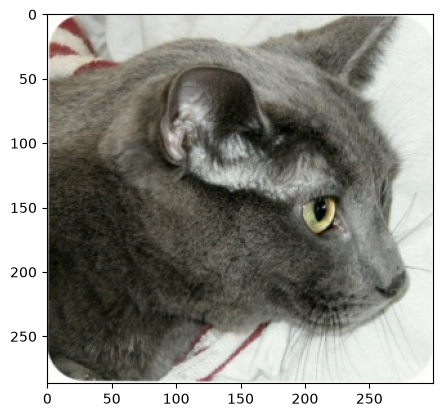

This image is 99.41% cat and 0.59% dog.


In [6]:
img = Image.open("PetImages/Cat/6779.jpg").convert("RGB")
plt.imshow(img)
plt.show()

img_tensor = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),   # scale to [0, 1], same as during training
])(img).unsqueeze(0).to(device)   # Create batch axis

model.eval()
with torch.no_grad():
    predictions = model(img_tensor)
score = float(torch.sigmoid(predictions[0][0]))
print(f"This image is {100 * (1 - score):.2f}% cat and {100 * score:.2f}% dog.")